In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import learning_curve

In [2]:
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

In [3]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [4]:
target = "house_price_inr"



PART F : POLYNOMIAL REGRESSION

Degree 2
RMSE : 8183089.094113434
R2 : 0.5626917978136475

Degree 3
RMSE : 8181382.291611445
R2 : 0.5628742034759397


C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


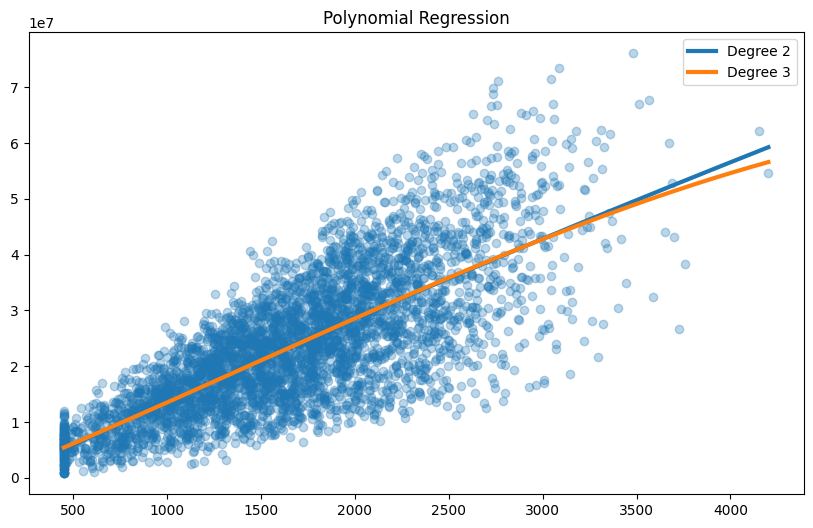

In [5]:
df_clean = df.copy()

print("\n")
print("="*60)
print("PART F : POLYNOMIAL REGRESSION")
print("="*60)

X = df_clean[['area_sqft']]
y = df_clean[target]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Degree 2

poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model2 = LinearRegression()

model2.fit(X_train_poly2,y_train)

pred2 = model2.predict(X_test_poly2)

print("\nDegree 2")

print("RMSE :",
      np.sqrt(mean_squared_error(y_test,pred2)))

print("R2 :",
      r2_score(y_test,pred2))

# Degree 3

poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model3 = LinearRegression()

model3.fit(X_train_poly3,y_train)

pred3 = model3.predict(X_test_poly3)

print("\nDegree 3")

print("RMSE :",
      np.sqrt(mean_squared_error(y_test,pred3)))

print("R2 :",
      r2_score(y_test,pred3))

# Visualization

X_grid = np.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1,1)

plt.figure(figsize=(10,6))

plt.scatter(X,y,alpha=0.3)

plt.plot(
    X_grid,
    model2.predict(poly2.transform(X_grid)),
    linewidth=3,
    label='Degree 2'
)

plt.plot(
    X_grid,
    model3.predict(poly3.transform(X_grid)),
    linewidth=3,
    label='Degree 3'
)

plt.legend()
plt.title("Polynomial Regression")
plt.show()